In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/customer_churn.csv"
)

df["monetary_log"] = np.log1p(
    df["monetary"]
)

In [2]:
features = [
    "frequency",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid",
    "customer_segment_encoded"
]

X = df[features]

y = df["monetary_log"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [4]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [5]:
y_pred_xgb = xgb.predict(
    X_test
)


In [6]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = mean_squared_error(
    y_test,
    y_pred_xgb
) ** 0.5

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

MAE: 0.09987120913603294
RMSE: 0.208438924642713
R2: 0.9474579902356773


In [7]:
xgb_results = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value":[
        mae_xgb,
        rmse_xgb,
        r2_xgb
    ]
})

xgb_results

,Metric,Value
0,MAE,0.099871
1,RMSE,0.208439
2,R2,0.947458


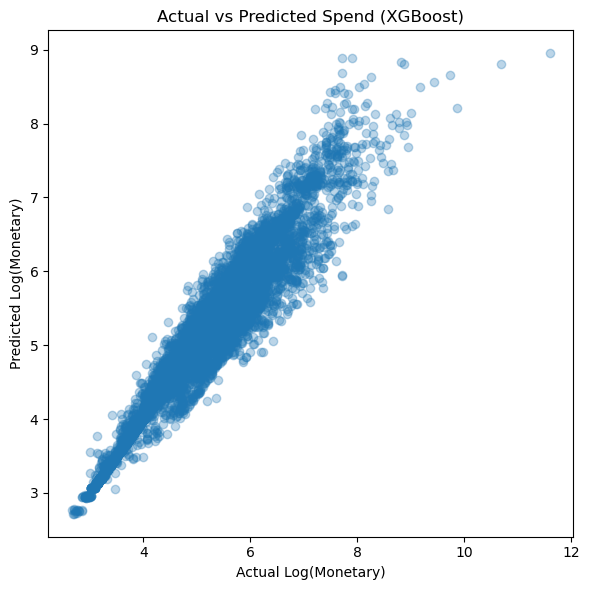

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.3
)

plt.title(
    "Actual vs Predicted Spend (XGBoost)"
)

plt.xlabel(
    "Actual Log(Monetary)"
)

plt.ylabel(
    "Predicted Log(Monetary)"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/spend_actual_vs_predicted_xgb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

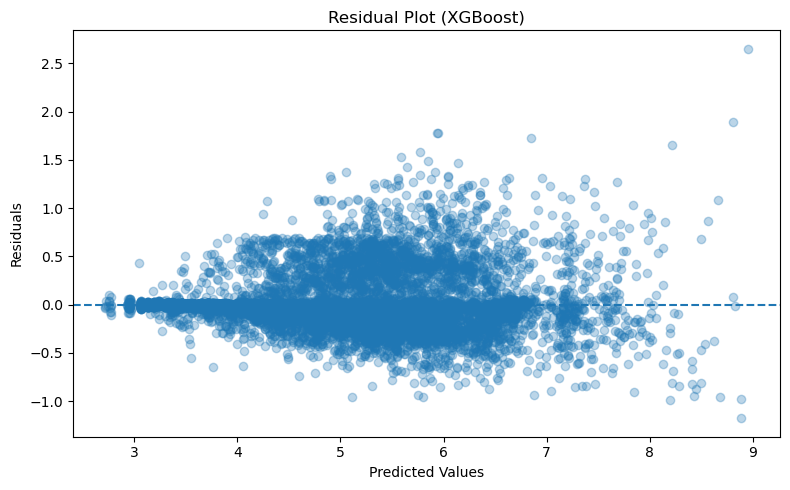

In [9]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_xgb,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Plot (XGBoost)"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/residual_plot_xgb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
1,avg_order_value,0.732375
6,customer_segment_encoded,0.181771
5,total_freight_paid,0.041901
0,frequency,0.015909
2,category_count,0.014019
4,avg_delivery_days,0.008479
3,avg_review_score,0.005546


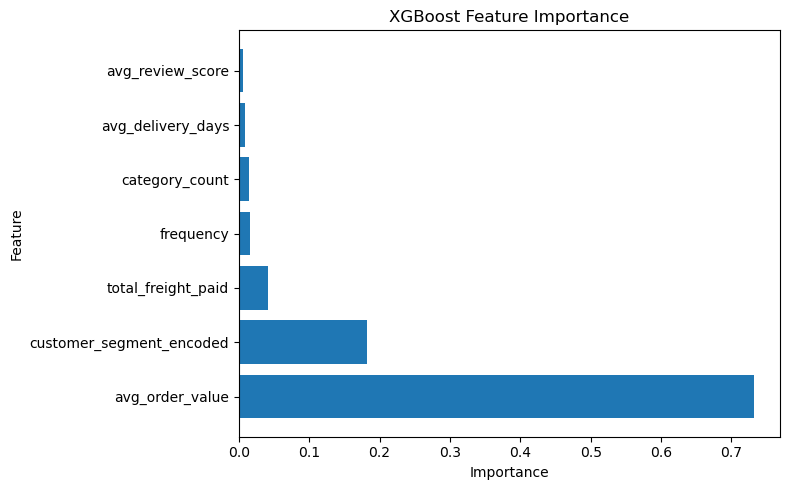

In [11]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/xgb_regression_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE":[
        0.426,
        0.086,
        mae_xgb
    ],
    "RMSE":[
        0.633,
        0.204,
        rmse_xgb
    ],
    "R2":[
        0.515,
        0.949,
        r2_xgb
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.426000,0.633000,0.515000
1,Random Forest,0.086000,0.204000,0.949000
2,XGBoost,0.099871,0.208439,0.947458


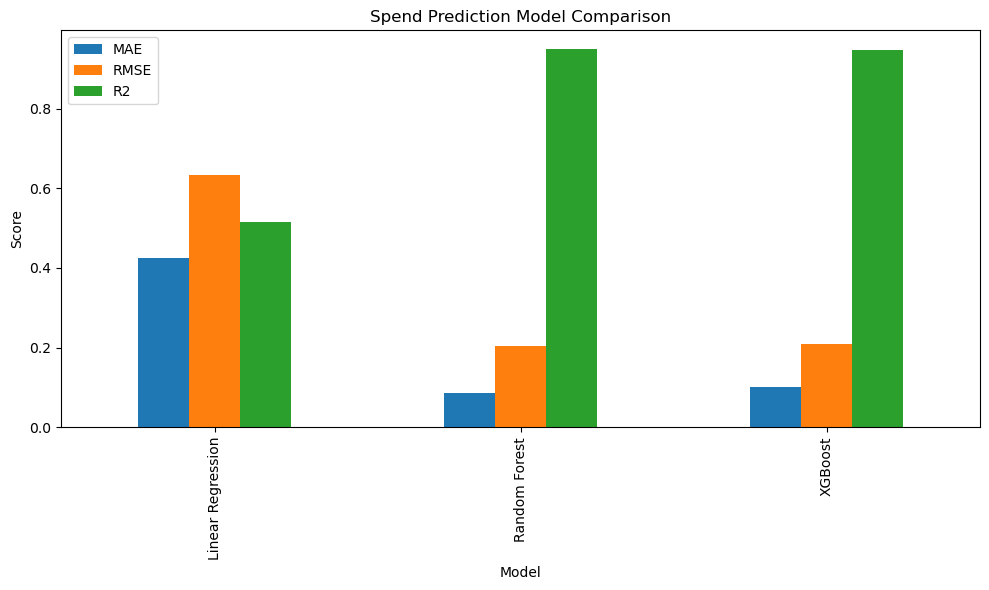

In [13]:
comparison.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Spend Prediction Model Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/spend_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
import joblib

joblib.dump(
    xgb,
    "../models/spend_prediction_xgb.pkl"
)

['../models/spend_prediction_xgb.pkl']

In [1]:
import pandas as pd
df = pd.read_csv(
    "../data/customer_churn.csv"
)

print(
    df["customer_segment"]
    .value_counts()
)

customer_segment
Active Customers          43122
Inactive Customers        33333
Dissatisfied Customers    14286
Loyal Customers            2886
VIP Customers              1792
Name: count, dtype: int64


In [2]:
df = pd.read_csv(
    "../data/customer_churn.csv"
)

print(df.head())

   frequency  monetary  avg_order_value  category_count  avg_review_score  \
0          1    141.90           141.90               1               5.0   
1          1     27.19            27.19               1               4.0   
2          1     86.22            86.22               1               3.0   
3          1     43.62            43.62               1               4.0   
4          1    196.89           196.89               1               5.0   

   avg_delivery_days  total_freight_paid  recency_days  customer_tenure_days  \
0                6.0               12.00           115                   115   
1                3.0                8.29           118                   118   
2               25.0               17.22           541                   541   
3               20.0               17.63           325                   325   
4               13.0               16.89           292                   292   

   cluster    customer_segment         clv  churn  custo